In [2]:
import ee
import os
import pandas as pd
import matplotlib.pyplot as plt
import hydropandas as hpd
from tsconfig import START_DATE, END_DATE, extent_to_rd, extent_to_ee, NDVI_START_DATE, NDVI_END_DATE
import numpy as np
import folium
import matplotlib.patches as mpatches

hpd.util.get_color_logger("INFO")
# pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)
# pd.set_option("display.width", None)

<RootLogger root (INFO)>

In [3]:
organisation = "rotterdam"

auth = ("__key__", "D5aclEis.RBUeIvKA6jrLVUzNpPATjvGyLXsLAx7P")

In [4]:
my_extent = extent_to_rd("gw") 
oc = hpd.read_lizard(
    extent=my_extent,
    which_timeseries=["hand", "diver", "diver_validated"],
    datafilters=None,
    combine_method="merge",
    organisation=organisation,
    auth=auth,
)

INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of monitoring wells: 2
INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of pages: 1


monitoring well: 100%|██████████| 2/2 [00:07<00:00,  3.74s/it]


In [5]:
m = oc.plots.interactive_map(
    color="red",
    zoom_start=20,
    tiles="Esri.WorldImagery",
    popup_width=350
)

lon_min, lat_min, lon_max, lat_max = extent_to_ee("ndvi")

folium.Rectangle(
    bounds=[(lat_min, lon_min), (lat_max, lon_max)],  # folium gebruikt (lat, lon)
    fill=False,
    weight=3
).add_to(m)

m

In [6]:
oc

,x,y,location,filename,source,unit,tube_nr,screen_top,screen_bottom,ground_level,tube_top,metadata_available,obs,lat,lon
name,,,,,,,,,,,,,,,
GMW000000035732001,96982.177209,441655.417641,133572-8,,lizard,m NAP,1,-6.96,-7.96,-5.73,-5.86,True,GroundwaterObs GMW000000035732001 -----metadat...,51.960297,4.543083
GMW000000046935001,96982.077663,441656.197665,133572-26,,lizard,m NAP,1,-6.83,-7.83,-5.63,-5.73,True,GroundwaterObs GMW000000046935001 -----metadat...,51.960304,4.543081


In [7]:
gw = oc.obs["GMW000000046935001"]
print(gw)

GroundwaterObs GMW000000046935001
-----metadata------
name : GMW000000046935001 
x : 96982.07766291886 
y : 441656.1976649185 
location : 133572-26 
filename :  
source : lizard 
unit : m NAP 
tube_nr : 1 
screen_top : -6.83 
screen_bottom : -7.83 
ground_level : -5.63 
tube_top : -5.73 
metadata_available : True 

-----time series------
                     value  flag  comment origin
peil_datum_tijd                                 
2021-04-08 23:00:00  -6.43     2  Gemeten   hand
2021-05-11 23:00:00  -6.39     2  Gemeten   hand
2021-06-09 23:00:00  -6.56     2  Gemeten   hand
2021-07-15 23:00:00  -6.62     2  Gemeten   hand
2021-08-09 23:00:00  -6.56     2  Gemeten   hand
...                    ...   ...      ...    ...
2026-03-16 05:07:01  -6.39     2           diver
2026-03-16 09:07:03  -6.41     2           diver
2026-03-16 13:07:04  -6.42     2           diver
2026-03-16 17:07:06  -6.42     2           diver
2026-03-16 21:07:07  -6.42     2           diver

[2212 rows x 4 columns

In [8]:
ts = gw["value"].copy()
ts.index = pd.to_datetime(ts.index)
ts = ts.dropna()

print(ts.index.min(), ts.index.max())
print(ts.shape)

2021-04-08 23:00:00 2026-03-16 21:07:07
(2212,)


In [9]:
ts_year = ts.loc[START_DATE:END_DATE]

ts_daily_raw = ts_year.resample("D").mean()

ts_daily = ts_daily_raw.interpolate(method="time")

is_interpolated = ts_daily_raw.isna()

In [10]:
percentile = 0.30

# === FIXED THRESHOLD ===
threshold_fixed = ts_daily.quantile(percentile)

# === VARIABLE THRESHOLD ===
monthly_threshold = (
    ts_daily
    .groupby(ts_daily.index.month)
    .quantile(percentile)
    .reindex(range(1, 13))          # zorg dat alle maanden bestaan
)

n_months_with_data = monthly_threshold.notna().sum()

if n_months_with_data < 6:
    print(
        f"Not enough data for variable threshold ({n_months_with_data} months). "
        "Variable threshold will not be used."
    )
    threshold_variable_smooth = None
else:
    monthly_threshold = monthly_threshold.interpolate(method="linear")

    threshold_variable = ts_daily.index.to_series().map(
        lambda d: monthly_threshold.loc[d.month]
    )

    threshold_variable_smooth = (
        threshold_variable
        .rolling(window=20, min_periods=1)
        .mean()
    )

# === KIES welke threshold wordt gebruikt voor DROOGTE ===
threshold = threshold_variable_smooth if threshold_variable_smooth is not None else threshold_fixed


In [11]:
is_drought_fixed = ts_daily <= threshold_fixed

if threshold_variable_smooth is not None:
    is_drought_variable = ts_daily <= threshold_variable_smooth
else:
    is_drought_variable = None

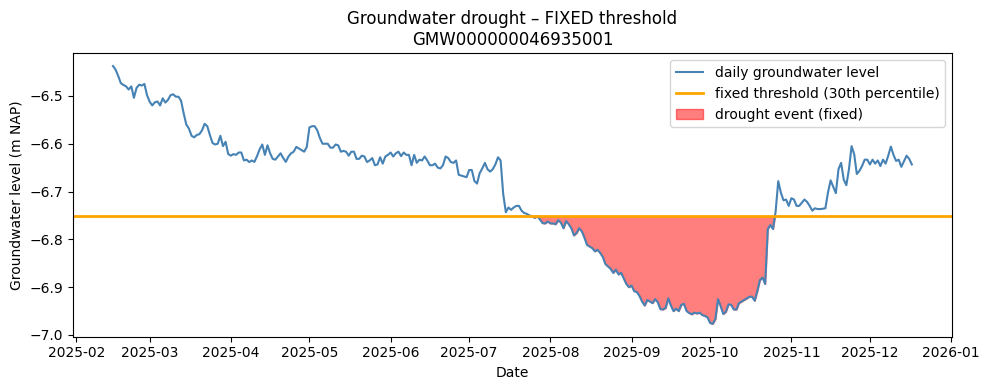

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    ts_daily.index,
    ts_daily,
    color="steelblue",
    linewidth=1.5,
    label="daily groundwater level",
)

ax.axhline(
    threshold_fixed,
    color="orange",
    linewidth=2,
    linestyle="-",
    label="fixed threshold (30th percentile)",
)

ax.fill_between(
    ts_daily.index,
    ts_daily,
    threshold_fixed,
    where=is_drought_fixed,
    color="red",
    alpha=0.5,
    label="drought event (fixed)",
    interpolate=True,
)

ax.set_ylabel("Groundwater level (m NAP)")
ax.set_xlabel("Date")
ax.set_title(f"Groundwater drought – FIXED threshold\n{gw.name}")
ax.legend()

plt.tight_layout()
plt.show()

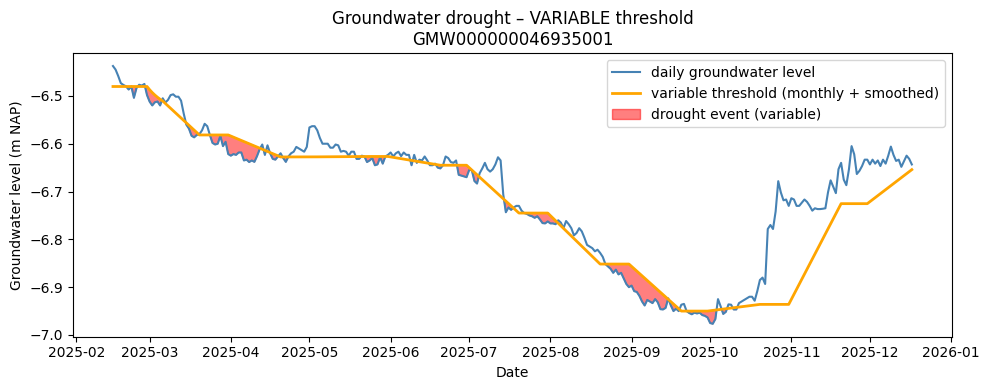

In [13]:
if threshold_variable_smooth is not None:
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        ts_daily.index,
        ts_daily,
        color="steelblue",
        linewidth=1.5,
        label="daily groundwater level",
    )

    ax.plot(
        threshold_variable_smooth.index,
        threshold_variable_smooth.values,
        color="orange",
        linewidth=2,
        label="variable threshold (monthly + smoothed)",
    )

    ax.fill_between(
        ts_daily.index,
        ts_daily,
        threshold_variable_smooth,
        where=is_drought_variable,
        color="red",
        alpha=0.5,
        label="drought event (variable)",
        interpolate=True,
    )

    ax.set_ylabel("Groundwater level (m NAP)")
    ax.set_xlabel("Date")
    ax.set_title(f"Groundwater drought – VARIABLE threshold\n{gw.name}")
    ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Variable threshold plot skipped: insufficient data.")


In [14]:
# =========================
# SAMENVATTING – FIXED THRESHOLD
# =========================
duration_fixed = is_drought_fixed.sum()
max_deficit_fixed = (threshold_fixed - ts_daily[is_drought_fixed]).max()

n_interpolated = is_interpolated.sum()

print("=== FIXED THRESHOLD (30th percentile) ===")
print(
    f"Drought duration (2024–2025): {duration_fixed} days. "
    f"{n_interpolated} days were interpolated."
)
print(f"Maximum deficit (2024–2025): {max_deficit_fixed:.2f} m\n")


# =========================
# SAMENVATTING – VARIABLE THRESHOLD
# =========================
if is_drought_variable is not None:
    duration_variable = is_drought_variable.sum()
    max_deficit_variable = (
        threshold_variable_smooth - ts_daily[is_drought_variable]
    ).max()

    print("=== VARIABLE THRESHOLD (monthly 30th percentile + smoothing) ===")
    print(
        f"Drought duration (2024–2025): {duration_variable} days. "
        f"{n_interpolated} days were interpolated."
    )
    print(f"Maximum deficit (2024–2025): {max_deficit_variable:.2f} m\n")
else:
    print("=== VARIABLE THRESHOLD ===")
    print("Not enough data to compute variable threshold.\n")


# =========================
# DAGELIJKS OVERZICHT (WAARDES + HERKOMST)
# =========================
origin_per_day = (
    gw[["value", "origin"]]
    .dropna()
    .assign(date=lambda df: df.index.normalize())
    .groupby("date")["origin"]
    .agg(lambda x: ",".join(sorted(set(x))))
)

summary = pd.DataFrame({
    "value": ts_daily,
    "interpolated": is_interpolated,
})

summary["origin"] = origin_per_day
summary.loc[summary["interpolated"], "origin"] = "interpolated"

# Toon de volledige tabel (alle rijen en kolommen)
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 2000):
    print(summary.to_string())



=== FIXED THRESHOLD (30th percentile) ===
Drought duration (2024–2025): 93 days. 2 days were interpolated.
Maximum deficit (2024–2025): 0.23 m

=== VARIABLE THRESHOLD (monthly 30th percentile + smoothing) ===
Drought duration (2024–2025): 127 days. 2 days were interpolated.
Maximum deficit (2024–2025): 0.06 m

                    value  interpolated        origin
peil_datum_tijd                                      
2025-02-15      -6.437500         False         diver
2025-02-16      -6.445000         False         diver
2025-02-17      -6.458333         False         diver
2025-02-18      -6.473333         False         diver
2025-02-19      -6.477143         False    diver,hand
2025-02-20      -6.480000         False         diver
2025-02-21      -6.486667         False         diver
2025-02-22      -6.480000         False         diver
2025-02-23      -6.504000         False         diver
2025-02-24      -6.483333         False         diver
2025-02-25      -6.476667         False 

In [15]:
# =========================
# COMPACTE & SNELLE EE INIT
# =========================

project = "afstuderen-481613"

try:
    ee.Initialize(project=project)
    print("Earth Engine initialized.")
except Exception:
    ee.Authenticate()
    ee.Initialize(project=project)
    print("Earth Engine authenticated and initialized.")

roi = ee.Geometry.Rectangle(extent_to_ee("ndvi"))

Earth Engine initialized.


In [16]:
def mask_s2_clouds(img):
    scl = img.select("SCL")
    mask = (
        scl.neq(3)   # cloud shadow
        .And(scl.neq(7))
        .And(scl.neq(8))
        .And(scl.neq(9))   # clouds
        .And(scl.neq(10))
        .And(scl.neq(11))  # snow
    )
    return img.updateMask(mask)


def add_ndvi_s2(img):
    return img.addBands(
        img.normalizedDifference(["B8", "B4"]).rename("NDVI")
    )


def reduce_ndvi(img):
    stats = img.select("NDVI").reduceRegion(
        reducer=ee.Reducer.mean().combine(ee.Reducer.count(), None, True),
        geometry=roi,
        scale=10,
        bestEffort=True,
        maxPixels=1e13,
    )

    return ee.Feature(None, {
        "date": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd"),
        "ndvi": stats.get("NDVI_mean"),
        "n_pixels": stats.get("NDVI_count"),
    })


col = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(roi)
    .filterDate(NDVI_START_DATE, NDVI_END_DATE)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
    .map(mask_s2_clouds)
    .map(add_ndvi_s2)
)

fc = col.map(reduce_ndvi)
features = fc.getInfo()["features"]

rows = []
for f in features:
    p = f["properties"]
    if p["ndvi"] is not None and p["n_pixels"] is not None:
        rows.append(p)

df_s2 = pd.DataFrame(rows)
df_s2["date"] = pd.to_datetime(df_s2["date"])
df_s2 = df_s2.sort_values("date").reset_index(drop=True)

In [17]:
roi_area = roi.area().getInfo()
expected_pixels = roi_area / (10 * 10)
min_required = expected_pixels * 0.70

df_s2 = df_s2[df_s2["n_pixels"] >= min_required].reset_index(drop=True)

print("Remaining NDVI scenes:", len(df_s2))

Remaining NDVI scenes: 97


In [18]:
ndvi_ts = df_s2.set_index("date")["ndvi"]

ndvi_daily_raw = ndvi_ts.resample("D").mean()
ndvi_daily = ndvi_daily_raw.interpolate("time")

In [19]:
ndvi_threshold_fixed = ndvi_daily.quantile(0.30)
is_ndvi_stress = ndvi_daily <= ndvi_threshold_fixed

In [20]:
# Use only the NDVI values between NDVI_START_DATE and NDVI_END_DATE for the threshold
ndvi_threshold_fixed = ndvi_daily.loc[NDVI_START_DATE:NDVI_END_DATE].quantile(0.30)

  gw_fixed = is_drought_fixed.reindex(common_index).fillna(False)



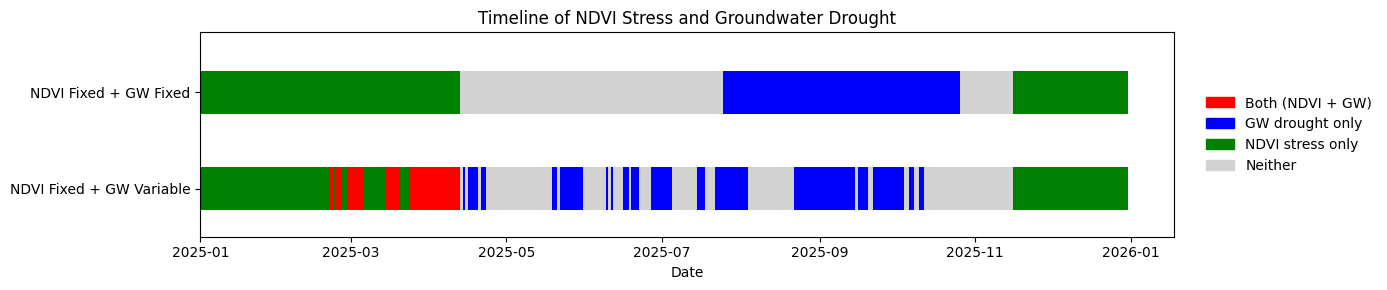

In [21]:
# =========================
# TWO TIMELINES: FIXED GW vs VARIABLE GW (both with fixed NDVI)
# =========================
# Fixed NDVI
# Build a common daily index that covers the available NDVI and groundwater ranges
# This makes the timeline code robust to different extents and date ranges.
indices = [i for i in [ts_daily.index, ndvi_daily.index] if len(i) > 0]
if len(indices) == 0:
    common_index = pd.DatetimeIndex([])
else:
    start = min(idx.min() for idx in indices)
    end = max(idx.max() for idx in indices)
    try:
        start_limit = pd.to_datetime(START_DATE)
        end_limit = pd.to_datetime(END_DATE)
        start = max(pd.to_datetime(start), start_limit)
        end = min(pd.to_datetime(end), end_limit)
    except Exception:
        pass
    common_index = pd.date_range(start=start.normalize(), end=end.normalize(), freq="D")
ndvi_fixed = is_ndvi_stress.reindex(common_index).fillna(False)
# Fixed groundwater
gw_fixed = is_drought_fixed.reindex(common_index).fillna(False)
# Variable groundwater
ts_daily_common = ts_daily.reindex(common_index)
monthly_threshold_gw = (
    ts_daily_common
    .groupby(ts_daily_common.index.month)
    .quantile(percentile)
    .reindex(range(1, 13))
    .interpolate(method="linear")
)
threshold_variable_gw = ts_daily_common.index.to_series().map(
    lambda d: monthly_threshold_gw.loc[d.month]
)
threshold_variable_gw_smooth = (
    threshold_variable_gw
    .rolling(window=20, min_periods=1)
    .mean()
)
gw_variable = (ts_daily_common <= threshold_variable_gw_smooth).fillna(False)
# --- Combinaties voor Fixed GW + Fixed NDVI ---
both_fixed = ndvi_fixed & gw_fixed
ndvi_only_fixed = ndvi_fixed & ~gw_fixed
gw_only_fixed = gw_fixed & ~ndvi_fixed
neither_fixed = ~(ndvi_fixed | gw_fixed)
# --- Combinaties voor Variable GW + Fixed NDVI ---
both_var = ndvi_fixed & gw_variable
ndvi_only_var = ndvi_fixed & ~gw_variable
gw_only_var = gw_variable & ~ndvi_fixed
neither_var = ~(ndvi_fixed | gw_variable)
# Functie om segmenten te bouwen
def build_segments(both, gw_only, ndvi_only):
    timeline = pd.Series("neither", index=common_index)
    timeline[both] = "both"
    timeline[gw_only] = "gw_only"
    timeline[ndvi_only] = "ndvi_only"
    blocks = timeline.ne(timeline.shift()).cumsum()
    return timeline.groupby(blocks).agg(
        start=lambda x: x.index[0],
        end=lambda x: x.index[-1],
        category="first"
    )
colors = {
    "both": "red",
    "gw_only": "blue",
    "ndvi_only": "green",
    "neither": "lightgrey",
}
segments_fixed = build_segments(both_fixed, gw_only_fixed, ndvi_only_fixed)
segments_var = build_segments(both_var, gw_only_var, ndvi_only_var)
fig, ax = plt.subplots(figsize=(14, 3))
# Y-posities en bar-height
y_fixed = 0.6
y_var = 0.2
bar_height = 0.18
# Plot Fixed GW + Fixed NDVI
for _, row in segments_fixed.iterrows():
    ax.barh(
        y_fixed,
        (row["end"] - row["start"]).days + 1,
        left=row["start"],
        color=colors[row["category"]],
        height=bar_height
    )
# Plot Variable GW + Fixed NDVI
for _, row in segments_var.iterrows():
    ax.barh(
        y_var,
        (row["end"] - row["start"]).days + 1,
        left=row["start"],
        color=colors[row["category"]],
        height=bar_height
    )
ax.set_yticks([y_fixed, y_var])
ax.set_yticklabels([
    "NDVI Fixed + GW Fixed",
    "NDVI Fixed + GW Variable"
])
ax.set_ylim(0, 0.85)
ax.set_xlabel("Date")
ax.set_title("Timeline of NDVI Stress and Groundwater Drought")
# Legenda rechts buiten de plot
import matplotlib.patches as mpatches
legend = [
    mpatches.Patch(color="red", label="Both (NDVI + GW)"),
    mpatches.Patch(color="blue", label="GW drought only"),
    mpatches.Patch(color="green", label="NDVI stress only"),
    mpatches.Patch(color="lightgrey", label="Neither"),
]
ax.legend(
    handles=legend,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
plt.tight_layout()
plt.show()

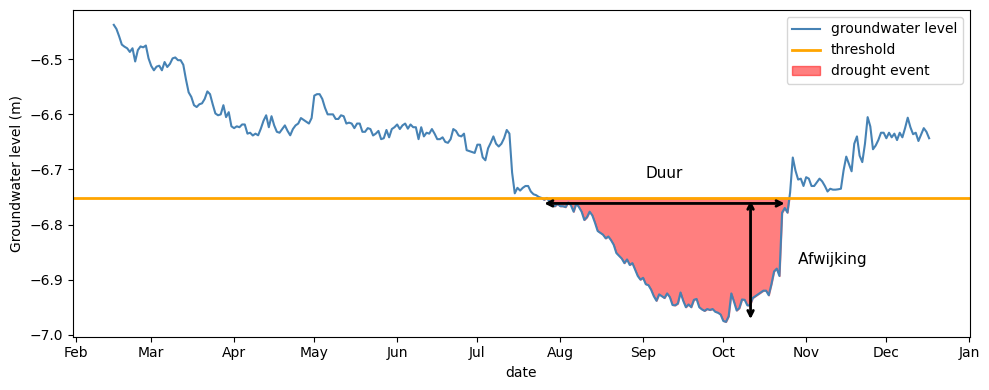

In [22]:
# Plot vaste threshold met aangepaste annotaties: duur boven het rode vlak, deficit-pijl en tekst verder naar rechts
import matplotlib.dates as mdates
from itertools import groupby
from operator import itemgetter
import pandas as pd

fig, ax = plt.subplots(figsize=(10, 4))

# Plot grondwaterstand en threshold
ax.plot(ts_daily.index, ts_daily, color="steelblue", linewidth=1.5, label="groundwater level")
ax.axhline(threshold_fixed, color="orange", linewidth=2, linestyle="-", label="threshold")

# Rood vlak: droogte
ax.fill_between(
    ts_daily.index,
    ts_daily,
    threshold_fixed,
    where=is_drought_fixed,
    color="red",
    alpha=0.5,
    label="drought event",
    interpolate=True,
)

# Zoek het langste aaneengesloten droogte-interval
indices = is_drought_fixed[is_drought_fixed].index
intervals = []
for k, g in groupby(enumerate(indices), lambda ix: ix[0] - ix[1].toordinal()):
    group = list(map(itemgetter(1), g))
    intervals.append(group)
longest = max(intervals, key=len) if intervals else []

if longest:
    start, end = longest[0], longest[-1]
    # Horizontale pijl voor duur
    ax.annotate(
        '', xy=(end, threshold_fixed-0.01), xytext=(start, threshold_fixed-0.01),
        arrowprops=dict(arrowstyle='<->', color='black', lw=2)
    )
    # Tekst boven het rode vlak
    ax.text(
        start + (end-start)/2, threshold_fixed+0.03,
        'Duur', ha='center', va='bottom', fontsize=11, color='black'
    )
    # Maximale afwijking (diepte) - pijl verder naar rechts
    drought_vals = ts_daily[longest]
    min_idx = drought_vals.idxmin()
    min_val = drought_vals.min()
    # Zoek een tijdstip 10% verder naar rechts binnen het interval, of het einde
    right_idx = pd.to_datetime(min_idx) + (end-start)*0.10
    # Corrigeer als buiten bereik
    if right_idx > end:
        right_idx = end
    # Y-waarden voor pijl
    y0 = threshold_fixed
    y1 = min_val
    ax.annotate(
        '', xy=(right_idx, y1), xytext=(right_idx, y0),
        arrowprops=dict(arrowstyle='<->', color='black', lw=2)
    )
    # Tekst rechts van de pijl
    ax.text(
        right_idx + pd.Timedelta(days=5), y1 + (y0-y1)/2,
        '       Afwijking', ha='left', va='center', fontsize=11, color='black', rotation=0
    )

ax.set_ylabel('Groundwater level (m)')
ax.set_xlabel('date')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()
plt.show()

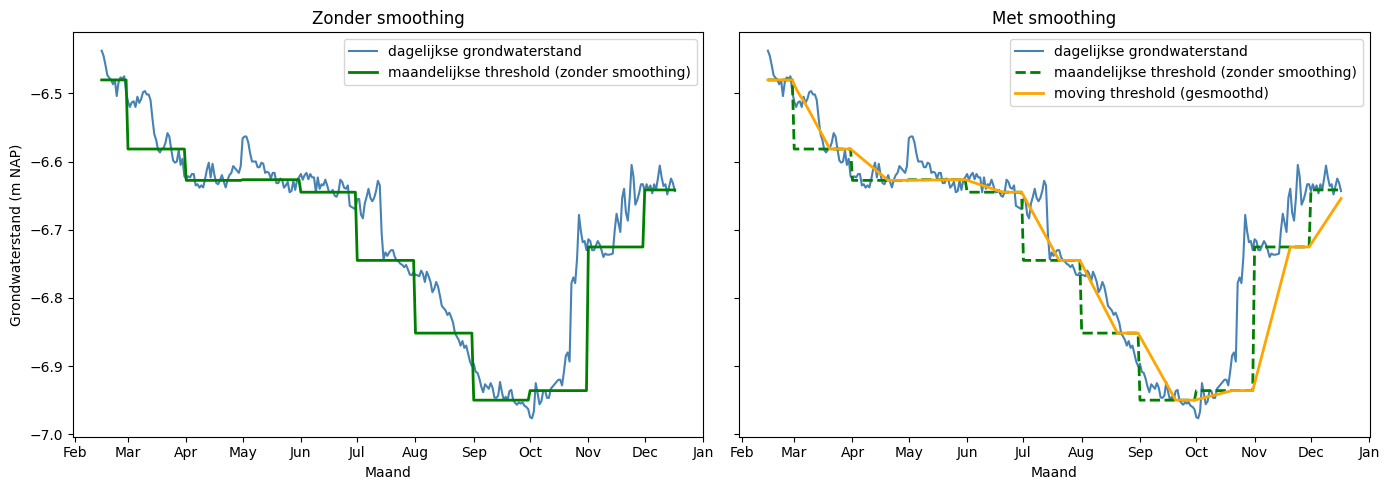

In [23]:
# Zet de twee figuren naast elkaar met een pijl ertussen: links zonder smoothing, rechts met smoothing, met alleen maanden op de x-as
import matplotlib.dates as mdates
import calendar

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Links: zonder smoothing
ax = axes[0]
ax.plot(ts_daily.index, ts_daily, color="steelblue", linewidth=1.5, label="dagelijkse grondwaterstand")
monthly_threshold_full = ts_daily.index.to_series().map(lambda d: monthly_threshold.loc[d.month])
ax.plot(ts_daily.index, monthly_threshold_full, color="green", linewidth=2, label="maandelijkse threshold (zonder smoothing)")
ax.set_title("Zonder smoothing")
ax.set_xlabel("Maand")
ax.set_ylabel("Grondwaterstand (m NAP)")
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Rechts: met smoothing
ax = axes[1]
ax.plot(ts_daily.index, ts_daily, color="steelblue", linewidth=1.5, label="dagelijkse grondwaterstand")
ax.plot(ts_daily.index, monthly_threshold_full, color="green", linewidth=2, linestyle="--", label="maandelijkse threshold (zonder smoothing)")
if threshold_variable_smooth is not None:
    ax.plot(threshold_variable_smooth.index, threshold_variable_smooth.values, color="orange", linewidth=2, label="moving threshold (gesmoothd)")
ax.set_title("Met smoothing")
ax.set_xlabel("Maand")
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()